In [18]:
import numpy as np
import pandas as pd
import random

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix

import matplotlib.pyplot as plt

import ssm

from ssm.util import find_permutation

# Generating $N$ 1-2-1 Trials

In [2]:
def generate_trials(num_trials, screen_width = 12):
    trials_list = []

    for i in range(num_trials):
        entry_hole = random.randint(1, screen_width-1)
        left_hole = random.randint(0, entry_hole-1)
        right_hole = random.randint(entry_hole+1, screen_width)
        exit_hole = random.randint(left_hole, right_hole)
        
        trials_list.append({
            'Entry': entry_hole,
            'Left Hole': left_hole,
            'Right Hole': right_hole,
            'Exit': exit_hole
        })

    return pd.DataFrame(trials_list)

In [3]:
def generate_sample_decisions(trials, strategy_function, probability = 0.1):

    input_variables = pd.DataFrame({
        'L1': np.abs(trials['Entry']-trials['Left Hole']),
        'L2': np.abs(trials['Exit']-trials['Left Hole']),
        'R1': np.abs(trials['Entry']-trials['Right Hole']),
        'R2': np.abs(trials['Exit']-trials['Right Hole']),
        'Direction': np.sign(trials['Exit'].shift(1)-trials['Entry']).fillna(0)
    })

    decisions = strategy_function(input_variables, probability)

    return decisions

In [4]:
def deterministic_greedy_selection(invar, probability):
    return invar['L1'] < invar['R1']

def deterministic_planning_selection(invar, probability):
    return (invar['L1']+invar['L2']) < (invar['R1']+invar['R2'])

def stochastic_greedy_selection(invar, probability):
    output = invar['L1'] < invar['R1']
    for i in range(len(output)):
        p = random.random()
        if p < probability:
            output[i] = ~output[i]
    return output

def stochastic_planning_selection(invar, probability):
    output = (invar['L1']+invar['L2']) < (invar['R1']+invar['R2'])
    for i in range(len(output)):
        p = random.random()
        if p < probability:
            output[i] = ~output[i]
    return output

def mixed_selection(invar, probability):
    output = (invar['L1']+invar['L2']) < (invar['R1']+invar['R2'])

    for i in range(len(output)):
        p = random.random()
        if p < probability:
            output[i] = (invar['L1'][i] < invar['R1'][i])
    
    return output

In [5]:
def plot_coeffecients_over_trials(trials, decisions):
    accuracy_over_trials = []
    coeffecients_over_trials = []
    loss_over_trials = []

    for i in range(int(len(trials)/100)-1):
        trials = trials[0: 100*(i+1)]
        decisions = decisions[0: 100*(i+1)]
        input_variables = pd.DataFrame({
                'L1': np.abs(trials['Entry']-trials['Left Hole']),
                'L2': np.abs(trials['Exit']-trials['Left Hole']),
                'R1': np.abs(trials['Entry']-trials['Right Hole']),
                'R2': np.abs(trials['Exit']-trials['Right Hole']),
                'Direction': np.sign(trials['Exit'].shift(1)-trials['Entry']).fillna(0)
            })

        X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(input_variables, decisions, test_size = 0.2)

        model = sklearn.linear_model.LogisticRegression().fit(X_train, y_train)

        accuracy = model.score(X_test, y_test)
        #print(f'Accuracy:', accuracy,'\n')

        accuracy_over_trials.append(accuracy)
        coeffecients_over_trials.append(pd.Series(model.coef_[0], index = X_train.columns))

        y_probs = model.predict_proba(X_test)
        loss_over_trials.append(log_loss(y_test, y_probs))

        #print(f'Coeffecients:\n', pd.Series(model.coef_[0], index=X_train.columns),'\n')
    coeffecients_over_trials = pd.DataFrame(coeffecients_over_trials)
    coeffecients_over_trials

    plt.plot([i * 100 for i in range(len(coeffecients_over_trials))], coeffecients_over_trials['L1'], label = 'L1')
    plt.plot([i * 100 for i in range(len(coeffecients_over_trials))], coeffecients_over_trials['R1'], label = 'R1')
    plt.plot([i * 100 for i in range(len(coeffecients_over_trials))], coeffecients_over_trials['L2'], label = 'L2')
    plt.plot([i * 100 for i in range(len(coeffecients_over_trials))], coeffecients_over_trials['R2'], label = 'R2')
    plt.legend()
    plt.xlabel('Number of Trials')
    plt.ylabel('Values of the Coeffecients')
    plt.show()

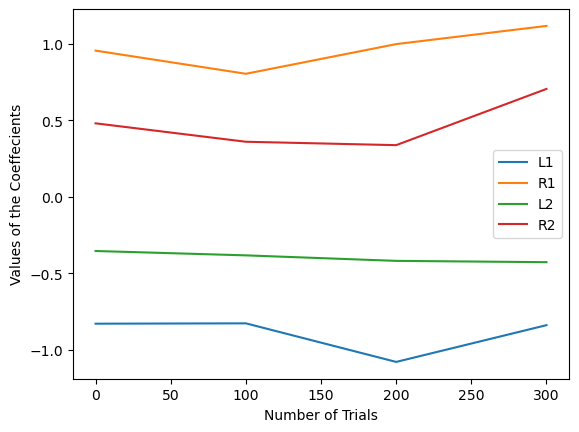

In [7]:
trials = generate_trials(500)
#trials
#decisions_greedy_deterministic = generate_sample_decisions(trials, deterministic_greedy_selection)
#plot_coeffecients_over_trials(trials, decisions_greedy_deterministic)
#decisions_planning_deterministic = generate_sample_decisions(trials, deterministic_planning_selection)
#plot_coeffecients_over_trials(trials, decisions_planning_deterministic)

mixed_selection_decisions = generate_sample_decisions(trials, mixed_selection, probability= 0.5)
plot_coeffecients_over_trials(trials, mixed_selection_decisions)

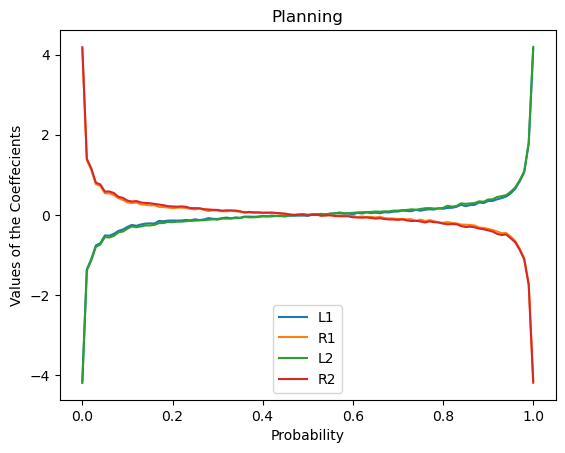

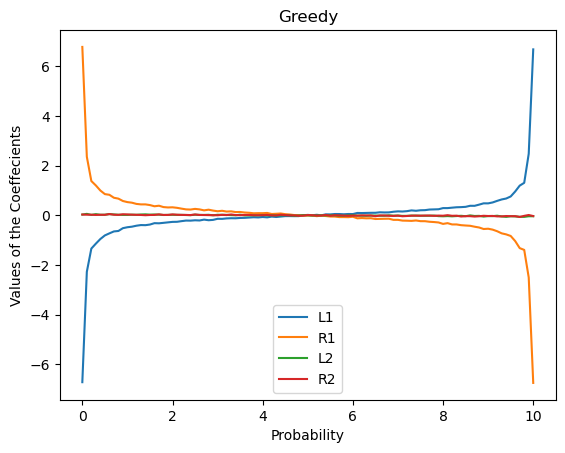

In [32]:
trials = generate_trials(5000)

accuracy_over_probs_g = []
coeffecients_over_probs_g = []
loss_over_probs_g = []
accuracy_over_probs_p = []
coeffecients_over_probs_p = []
loss_over_probs_p = []

input_variables = pd.DataFrame({
                'L1': np.abs(trials['Entry']-trials['Left Hole']),
                'L2': np.abs(trials['Exit']-trials['Left Hole']),
                'R1': np.abs(trials['Entry']-trials['Right Hole']),
                'R2': np.abs(trials['Exit']-trials['Right Hole']),
                'Direction': np.sign(trials['Exit'].shift(1)-trials['Entry']).fillna(0)
            })

granularity = 101

for i in range(granularity):

    decisions_greedy = stochastic_greedy_selection(input_variables, probability= i/(granularity-1))
    decisions_planning = stochastic_planning_selection(input_variables, probability = i/(granularity-1))

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(input_variables, decisions_greedy, test_size = 0.2)

    model = sklearn.linear_model.LogisticRegression().fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)
    accuracy_over_probs_g.append(accuracy)
    coeffecients_over_probs_g.append(pd.Series(model.coef_[0], index = X_train.columns))

    y_probs = model.predict_proba(X_test)
    loss_over_probs_p.append(log_loss(y_test, y_probs))

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(input_variables, decisions_planning, test_size = 0.2)

    model = sklearn.linear_model.LogisticRegression().fit(X_train, y_train)

    accuracy = model.score(X_test, y_test)
    accuracy_over_probs_p.append(accuracy)
    coeffecients_over_probs_p.append(pd.Series(model.coef_[0], index = X_train.columns))

    y_probs = model.predict_proba(X_test)
    loss_over_probs_p.append(log_loss(y_test, y_probs))

coeffecients_over_probs_p = pd.DataFrame(coeffecients_over_probs_p)
coeffecients_over_probs_g = pd.DataFrame(coeffecients_over_probs_g)

plt.plot([i/(granularity-1) for i in range(len(coeffecients_over_probs_p))], coeffecients_over_probs_p['L1'], label = 'L1')
plt.plot([i/(granularity-1) for i in range(len(coeffecients_over_probs_p))], coeffecients_over_probs_p['R1'], label = 'R1')
plt.plot([i/(granularity-1) for i in range(len(coeffecients_over_probs_p))], coeffecients_over_probs_p['L2'], label = 'L2')
plt.plot([i/(granularity-1) for i in range(len(coeffecients_over_probs_p))], coeffecients_over_probs_p['R2'], label = 'R2')
plt.legend()
plt.xlabel('Probability')
plt.ylabel('Values of the Coeffecients')
plt.title('Planning')
plt.show()

plt.plot([i * 0.1 for i in range(len(coeffecients_over_probs_g))], coeffecients_over_probs_g['L1'], label = 'L1')
plt.plot([i * 0.1 for i in range(len(coeffecients_over_probs_g))], coeffecients_over_probs_g['R1'], label = 'R1')
plt.plot([i * 0.1 for i in range(len(coeffecients_over_probs_g))], coeffecients_over_probs_g['L2'], label = 'L2')
plt.plot([i * 0.1 for i in range(len(coeffecients_over_probs_g))], coeffecients_over_probs_g['R2'], label = 'R2')
plt.legend()
plt.xlabel('Probability')
plt.ylabel('Values of the Coeffecients')
plt.title('Greedy')
plt.show()

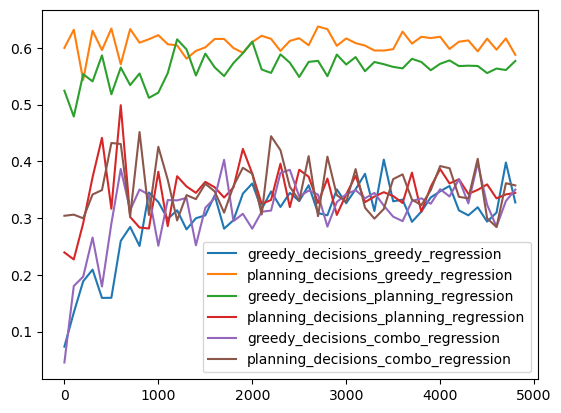

In [11]:
trials = generate_trials(5000)

input_variables = pd.DataFrame({
                'L1': np.abs(trials['Entry']-trials['Left Hole']),
                'L2': np.abs(trials['Exit']-trials['Left Hole']),
                'R1': np.abs(trials['Entry']-trials['Right Hole']),
                'R2': np.abs(trials['Exit']-trials['Right Hole']),
                'Direction': np.sign(trials['Exit'].shift(1)-trials['Entry']).fillna(0)
            })


input_variables_2 = pd.DataFrame({
    "greedy_diff": input_variables['L1'] - input_variables['R1'],
    "second_level_diff": input_variables['L2'] - input_variables['R2'],
    "planning_diff": (input_variables['L1'] + input_variables['L2']) - (input_variables['R1'] + input_variables['R2']),
    "direction": input_variables['Direction']
})

decisions_greedy = stochastic_greedy_selection(input_variables, probability = 0.05)
decisions_planning = stochastic_planning_selection(input_variables, probability = 0.05)

def return_loss_plot(input_vector, decisions_vector):
    loss_plot = []

    for i in range(int(len(trials)/100)-1):
        input_in_loop = input_vector[0:(i+1)*100]
        decisions_in_loop = decisions_vector[0:(i+1)*100]

        X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(input_in_loop, 
                                                    decisions_in_loop, test_size = 0.2)
        model = sklearn.linear_model.LogisticRegression().fit(X_train, y_train)

        y_probs = model.predict_proba(X_test)
        loss_plot.append(log_loss(y_test, y_probs))

    return loss_plot

greedy_decisions_greedy_regression = return_loss_plot(input_variables_2[['greedy_diff']], decisions_greedy)
planning_decisions_greedy_regression = return_loss_plot(input_variables_2[['greedy_diff']], decisions_planning)
greedy_decisions_planning_regression = return_loss_plot(input_variables_2[['planning_diff']], decisions_greedy)
planning_decisions_planning_regression = return_loss_plot(input_variables_2[['planning_diff']], decisions_planning)
greedy_decisions_combo_regression = return_loss_plot(input_variables_2[['greedy_diff', 'second_level_diff']], decisions_greedy)
planning_decisions_combo_regression = return_loss_plot(input_variables_2[['greedy_diff', 'second_level_diff']], decisions_planning)

plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], greedy_decisions_greedy_regression,
         label = 'greedy_decisions_greedy_regression')
plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], planning_decisions_greedy_regression,
         label = 'planning_decisions_greedy_regression')
plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], greedy_decisions_planning_regression,
         label = 'greedy_decisions_planning_regression')
plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], planning_decisions_planning_regression,
         label = 'planning_decisions_planning_regression')
plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], greedy_decisions_combo_regression,
         label = 'greedy_decisions_combo_regression')
plt.plot([i * 100 for i in range(len(greedy_decisions_greedy_regression))], planning_decisions_combo_regression,
         label = 'planning_decisions_combo_regression')
plt.legend()


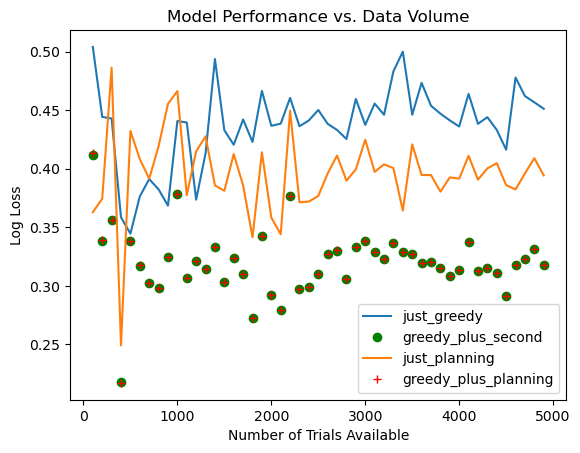

In [16]:
trials = generate_trials(5000)

input_variables = pd.DataFrame({
                'L1': np.abs(trials['Entry']-trials['Left Hole']),
                'L2': np.abs(trials['Exit']-trials['Left Hole']),
                'R1': np.abs(trials['Entry']-trials['Right Hole']),
                'R2': np.abs(trials['Exit']-trials['Right Hole']),
                'Direction': np.sign(trials['Exit'].shift(1)-trials['Entry']).fillna(0)
            })


input_variables_2 = pd.DataFrame({
    "greedy_diff": input_variables['L1'] - input_variables['R1'],
    "second_level_diff": input_variables['L2'] - input_variables['R2'],
    "planning_diff": (input_variables['L1'] + input_variables['L2']) - (input_variables['R1'] + input_variables['R2']),
    "direction": input_variables['Direction']
})

def return_loss_plot(input_vector, decisions_vector):
    loss_plot = []
    
    # Calculate exactly how many chunks we will process
    num_chunks = int(len(input_vector) / 100) - 1

    for i in range(num_chunks):
        input_in_loop = input_vector[0:(i+1)*100]
        decisions_in_loop = decisions_vector[0:(i+1)*100]

        # Added random_state for reproducible, stable splits
        X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
            input_in_loop, decisions_in_loop, test_size=0.2, random_state=42
        )
        
        model = sklearn.linear_model.LogisticRegression().fit(X_train, y_train)

        y_probs = model.predict_proba(X_test)
        loss_plot.append(log_loss(y_test, y_probs))

    return loss_plot

mixed_selection_decisions = mixed_selection(input_variables, probability=0.5)

just_greedy = return_loss_plot(input_variables_2[['greedy_diff']], mixed_selection_decisions)
greedy_plus_second = return_loss_plot(input_variables_2[['greedy_diff', 'second_level_diff']], mixed_selection_decisions)
just_planning = return_loss_plot(input_variables_2[['planning_diff']], mixed_selection_decisions)
greedy_plus_planning = return_loss_plot(input_variables_2[['greedy_diff', 'planning_diff']], mixed_selection_decisions)

# --- FIX: Generate an x-axis that exactly matches the length of the loss arrays ---
x_axis = [(i + 1) * 100 for i in range(len(just_greedy))]

plt.plot(x_axis, just_greedy, label='just_greedy', )
plt.plot(x_axis, greedy_plus_second, 'go', label='greedy_plus_second')
plt.plot(x_axis, just_planning, label='just_planning')
plt.plot(x_axis, greedy_plus_planning, 'r+', label='greedy_plus_planning')

plt.xlabel("Number of Trials Available")
plt.ylabel("Log Loss")
plt.title("Model Performance vs. Data Volume")
plt.legend()
plt.show()

In [19]:
models_to_evaluate = {
    "Just Greedy": ['greedy_diff'],
    "Greedy + Second Level": ['greedy_diff', 'second_level_diff'],
    "Just Planning": ['planning_diff'],
    "Greedy + Planning": ['greedy_diff', 'planning_diff'] # Reminder: mathematically identical to Greedy + Second Level
}

print("=== MODEL EVALUATION SUMMARY ===\n")

for model_name, features in models_to_evaluate.items():
    # Isolate the specific features for this loop
    X = input_variables_2[features]
    y = mixed_selection_decisions

    # Create a stable 80/20 split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the model
    model = LogisticRegression().fit(X_train, y_train)

    # Generate predictions
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # scikit-learn's log_loss is the negative log-likelihood per sample.
    # Multiplying by -1 gives you the true Log Likelihood (closer to 0 is better).
    log_likelihood = -log_loss(y_test, y_probs) 

    # Print the formatted results
    print(f"Model: {model_name}")
    print(f"  Log Likelihood: {log_likelihood:.4f}")
    print(f"  Accuracy:       {accuracy:.2%}")
    print(f"  Intercept:      {model.intercept_[0]:.4f}")
    
    # Print the individual coefficients
    for feat, coef in zip(features, model.coef_[0]):
        print(f"  Coef ({feat}):  {coef:.4f}")
        
    print("-" * 40)

=== MODEL EVALUATION SUMMARY ===

Model: Just Greedy
  Log Likelihood: -0.4491
  Accuracy:       85.30%
  Intercept:      -0.4925
  Coef (greedy_diff):  -0.5050
----------------------------------------
Model: Greedy + Second Level
  Log Likelihood: -0.3198
  Accuracy:       84.80%
  Intercept:      -0.6728
  Coef (greedy_diff):  -0.8342
  Coef (second_level_diff):  -0.4402
----------------------------------------
Model: Just Planning
  Log Likelihood: -0.3937
  Accuracy:       84.80%
  Intercept:      -0.5054
  Coef (planning_diff):  -0.4538
----------------------------------------
Model: Greedy + Planning
  Log Likelihood: -0.3198
  Accuracy:       84.80%
  Intercept:      -0.6731
  Coef (greedy_diff):  -0.3942
  Coef (planning_diff):  -0.4405
----------------------------------------


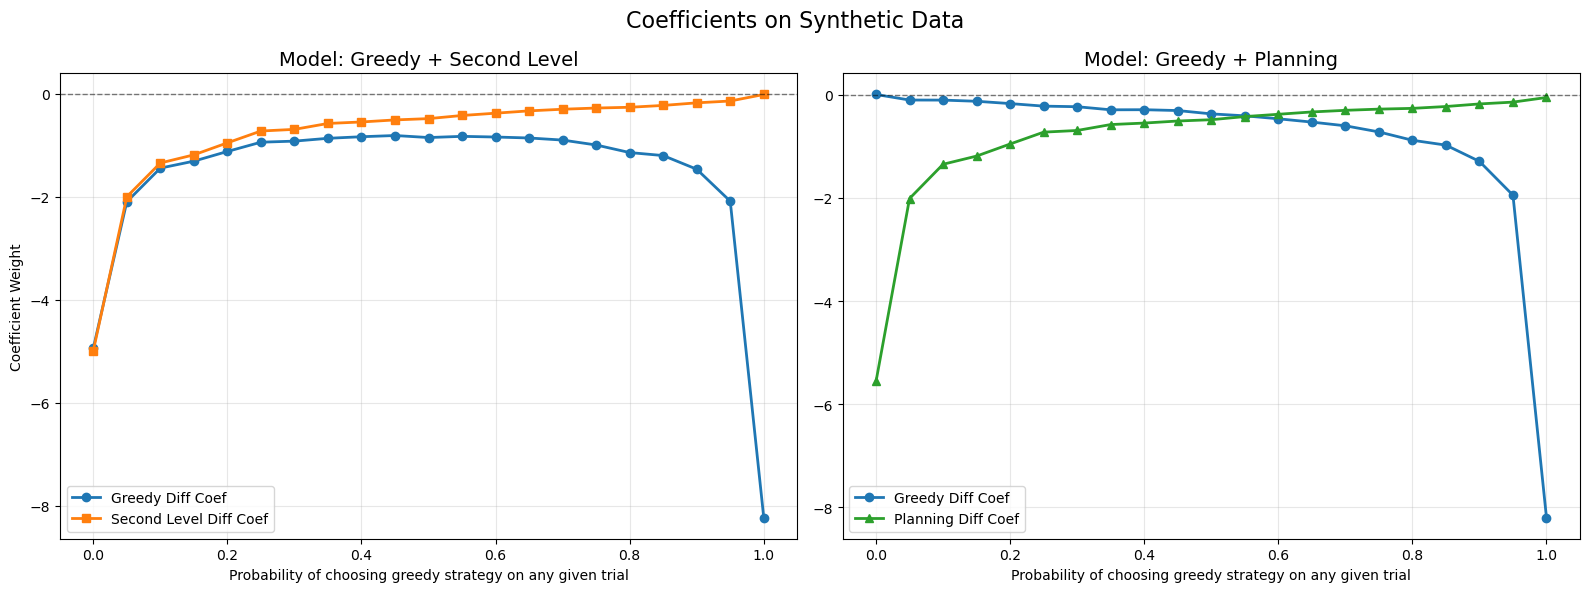

In [23]:
probabilities = np.linspace(0, 1, 21)

# Storage for the extracted coefficients
m1_greedy_coefs = []
m1_second_coefs = []

m2_greedy_coefs = []
m2_planning_coefs = []

for p in probabilities:
    # 1. Generate the target variable for the current probability
    current_decisions = mixed_selection(input_variables, probability=p)
    
    # 2. Setup the feature spaces
    X1 = input_variables_2[['greedy_diff', 'second_level_diff']]
    X2 = input_variables_2[['greedy_diff', 'planning_diff']]
    
    # 3. Fit Model 1 (Greedy + Second Level)
    # Fitting on the whole dataset to extract the most stable "true" coefficients
    model1 = LogisticRegression().fit(X1, current_decisions)
    m1_greedy_coefs.append(model1.coef_[0][0])
    m1_second_coefs.append(model1.coef_[0][1])
    
    # 4. Fit Model 2 (Greedy + Planning)
    model2 = LogisticRegression().fit(X2, current_decisions)
    m2_greedy_coefs.append(model2.coef_[0][0])
    m2_planning_coefs.append(model2.coef_[0][1])

# --- Plotting the Results ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Coefficients on Synthetic Data", fontsize=16)

# Plot Model 1
ax1.plot(probabilities, m1_greedy_coefs, marker='o', label='Greedy Diff Coef', color='tab:blue', linewidth=2)
ax1.plot(probabilities, m1_second_coefs, marker='s', label='Second Level Diff Coef', color='tab:orange', linewidth=2)
ax1.set_title("Model: Greedy + Second Level", fontsize=14)
ax1.set_xlabel("Probability of choosing greedy strategy on any given trial")
ax1.set_ylabel("Coefficient Weight")
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Model 2
ax2.plot(probabilities, m2_greedy_coefs, marker='o', label='Greedy Diff Coef', color='tab:blue', linewidth=2)
ax2.plot(probabilities, m2_planning_coefs, marker='^', label='Planning Diff Coef', color='tab:green', linewidth=2)
ax2.set_title("Model: Greedy + Planning", fontsize=14)
ax2.set_xlabel("Probability of choosing greedy strategy on any given trial")
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# GLM-HMM Model

In [48]:
num_states = 3
obs_dim = 1
num_categories = 2
input_dim = 3

# Make a GLM-HMM
true_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", 
                   observation_kwargs=dict(C=num_categories), transitions="standard")

gen_weights = np.array([[[-6, 0, 0]], [[-3, -3, 1]], [[-1, -1, 4]]])
gen_log_trans_mat = np.log(np.array([[[0.98, 0.01, 0.01], [0.05, 0.92, 0.03], [0.03, 0.03, 0.94]]]))
true_glmhmm.observations.params = gen_weights
true_glmhmm.transitions.params = gen_log_trans_mat



Text(0.5, 1.0, 'Generative transition matrix')

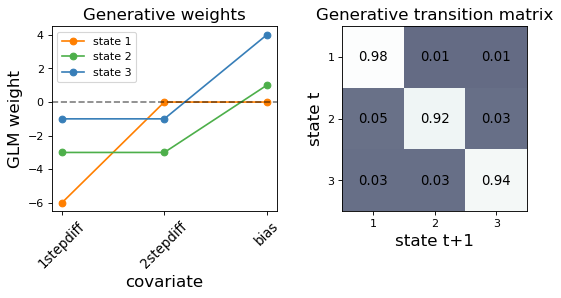

In [49]:
fig = plt.figure(figsize=(8, 3), dpi=80, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)
cols = ['#ff7f00', '#4daf4a', '#377eb8']
for k in range(num_states):
    plt.plot(range(input_dim), gen_weights[k][0], marker='o',
             color=cols[k], linestyle='-',
             lw=1.5, label="state " + str(k+1))
plt.yticks(fontsize=10)
plt.ylabel("GLM weight", fontsize=15)
plt.xlabel("covariate", fontsize=15)
plt.xticks([0, 1, 2], ['1stepdiff', '2stepdiff', 'bias'], fontsize=12, rotation=45)
plt.axhline(y=0, color="k", alpha=0.5, ls="--")
plt.legend()
plt.title("Generative weights", fontsize = 15)

plt.subplot(1, 2, 2)
gen_trans_mat = np.exp(gen_log_trans_mat)[0]
plt.imshow(gen_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(gen_trans_mat.shape[0]):
    for j in range(gen_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(gen_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, num_states - 0.5)
plt.xticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.ylim(num_states - 0.5, -0.5)
plt.ylabel("state t", fontsize = 15)
plt.xlabel("state t+1", fontsize = 15)
plt.title("Generative transition matrix", fontsize = 15)

In [ ]:
total_trials = len(trials)
full_inpts = np.ones((len(trials), 3))

full_inpts[:, 0] = input_variables_2['greedy_diff']
full_inpts[:, 1] = input_variables_2['second_level_diff']

num_sess = 5  # Change this to whatever number you need

# 3. Split the large array into a list of smaller session arrays
inpts_per_session = np.array_split(full_inpts, num_sess)

true_latents, true_choices = [], []

# 4. Iterate through each chunk
for sess_inpts in inpts_per_session:
    # Get the actual number of trials in this specific chunk
    num_trials_in_sess = len(sess_inpts)
    
    # Sample using just this chunk's inputs
    true_z, true_y = true_glmhmm.sample(num_trials_in_sess, input=sess_inpts)
    
    true_latents.append(true_z)
    true_choices.append(true_y)

In [58]:
true_ll = true_glmhmm.log_probability(true_choices, inputs=inpts_per_session) 
print("true ll = " + str(true_ll))

true ll = -988.5828664378157


In [60]:
new_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", 
                   observation_kwargs=dict(C=num_categories), transitions="standard")

N_iters = 200
fit_ll = new_glmhmm.fit(true_choices, inputs=inpts_per_session, method="em", num_iters=N_iters, tolerance=10**-4)

  0%|          | 0/200 [00:00<?, ?it/s]

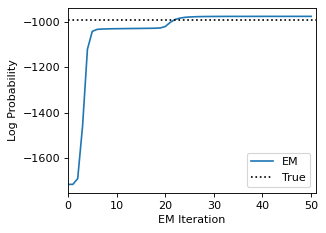

In [61]:
fig = plt.figure(figsize=(4, 3), dpi=80, facecolor='w', edgecolor='k')
plt.plot(fit_ll, label="EM")
plt.plot([0, len(fit_ll)], true_ll * np.ones(2), ':k', label="True")
plt.legend(loc="lower right")
plt.xlabel("EM Iteration")
plt.xlim(0, len(fit_ll))
plt.ylabel("Log Probability")
plt.show()

Text(0.5, 1.0, 'Weight recovery')

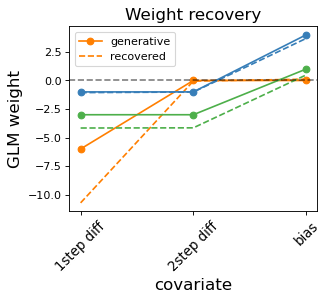

In [90]:
new_glmhmm.permute(find_permutation(true_latents[0], new_glmhmm.most_likely_states(true_choices[0], input=inpts_per_session[0])))

fig = plt.figure(figsize=(4, 3), dpi=80, facecolor='w', edgecolor='k')
cols = ['#ff7f00', '#4daf4a', '#377eb8']
recovered_weights = new_glmhmm.observations.params
for k in range(num_states):
    if k ==0:
        plt.plot(range(input_dim), gen_weights[k][0], marker='o',
                 color=cols[k], linestyle='-',
                 lw=1.5, label="generative")
        plt.plot(range(input_dim), recovered_weights[k][0], color=cols[k],
                     lw=1.5,  label = "recovered", linestyle = '--')
    else:
        plt.plot(range(input_dim), gen_weights[k][0], marker='o',
                 color=cols[k], linestyle='-',
                 lw=1.5, label="")
        plt.plot(range(input_dim), recovered_weights[k][0], color=cols[k],
                     lw=1.5,  label = '', linestyle = '--')
plt.yticks(fontsize=10)
plt.ylabel("GLM weight", fontsize=15)
plt.xlabel("covariate", fontsize=15)
plt.xticks([0, 1, 2], ['1step diff', '2step diff', 'bias'], fontsize=12, rotation=45)
plt.axhline(y=0, color="k", alpha=0.5, ls="--")
plt.legend()
plt.title("Weight recovery", fontsize=15)

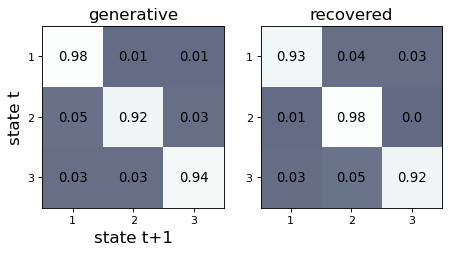

In [63]:
fig = plt.figure(figsize=(5, 2.5), dpi=80, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)
gen_trans_mat = np.exp(gen_log_trans_mat)[0]
plt.imshow(gen_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(gen_trans_mat.shape[0]):
    for j in range(gen_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(gen_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, num_states - 0.5)
plt.xticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.ylim(num_states - 0.5, -0.5)
plt.ylabel("state t", fontsize = 15)
plt.xlabel("state t+1", fontsize = 15)
plt.title("generative", fontsize = 15)


plt.subplot(1, 2, 2)
recovered_trans_mat = np.exp(new_glmhmm.transitions.log_Ps)
plt.imshow(recovered_trans_mat, vmin=-0.8, vmax=1, cmap='bone')
for i in range(recovered_trans_mat.shape[0]):
    for j in range(recovered_trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(recovered_trans_mat[i, j], decimals=2)), ha="center", va="center",
                        color="k", fontsize=12)
plt.xlim(-0.5, num_states - 0.5)
plt.xticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.yticks(range(0, num_states), ('1', '2', '3'), fontsize=10)
plt.ylim(num_states - 0.5, -0.5)
plt.title("recovered", fontsize = 15)
plt.subplots_adjust(0, 0, 1, 1)

In [86]:
prior_sigma = 100
prior_alpha = 2
map_glmhmm = ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", 
             observation_kwargs=dict(C=num_categories,prior_sigma=prior_sigma),
             transitions="sticky", transition_kwargs=dict(alpha=prior_alpha,kappa=0))

In [87]:
_ = map_glmhmm.fit(true_choices, inputs=inpts_per_session, method="em", num_iters=N_iters, tolerance=10**-4)

  0%|          | 0/200 [00:00<?, ?it/s]

In [79]:
true_likelihood = true_glmhmm.log_likelihood(true_choices, inputs=inpts_per_session)
mle_final_ll = new_glmhmm.log_likelihood(true_choices, inputs=inpts_per_session) 
map_final_ll = map_glmhmm.log_likelihood(true_choices, inputs=inpts_per_session) 

Text(0, 0.5, 'loglikelihood')

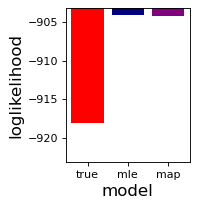

In [80]:
fig = plt.figure(figsize=(2, 2.5), dpi=80, facecolor='w', edgecolor='k')
loglikelihood_vals = [true_likelihood, mle_final_ll, map_final_ll]
colors = ['Red', 'Navy', 'Purple']
for z, occ in enumerate(loglikelihood_vals):
    plt.bar(z, occ, width = 0.8, color = colors[z])
plt.ylim((true_likelihood-5, true_likelihood+15))
plt.xticks([0, 1, 2], ['true', 'mle', 'map'], fontsize = 10)
plt.xlabel('model', fontsize = 15)
plt.ylabel('loglikelihood', fontsize=15)